In [51]:
#Monday #Alex Velasquez, Dillan Andrews
#Wednesday #Alex Velasquez, Dillan Andrews
#https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset?resource=download

In [52]:
#imported the necessary libraries to run the model
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [53]:
#This loads the breast cancer dataset so we can start working with it
df = pd.read_csv('breast_cancer.csv')
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [55]:
#remove any missing data to make sure the model doesn't run into errors
df.dropna(inplace=True)
print(df.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [58]:
#this separates the data into inputs and output
X = df.iloc[:, 2:]
y = df.iloc[:, 1]

In [59]:
#this splits the data so the model can train on one part and be tested on new data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [60]:
#This builds and trains the svm model using the RBF kernel
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')
print("Training the SVM model...")
svm_classifier.fit(X_train, y_train)
print("Training complete!")

Training the SVM model...
Training complete!


In [61]:
#this uses the trained model to predict results on the test data.
y_pred = svm_classifier.predict(X_test)


In [62]:
#Accuracy shows how accurate the model is.
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")



Accuracy: 93.57%


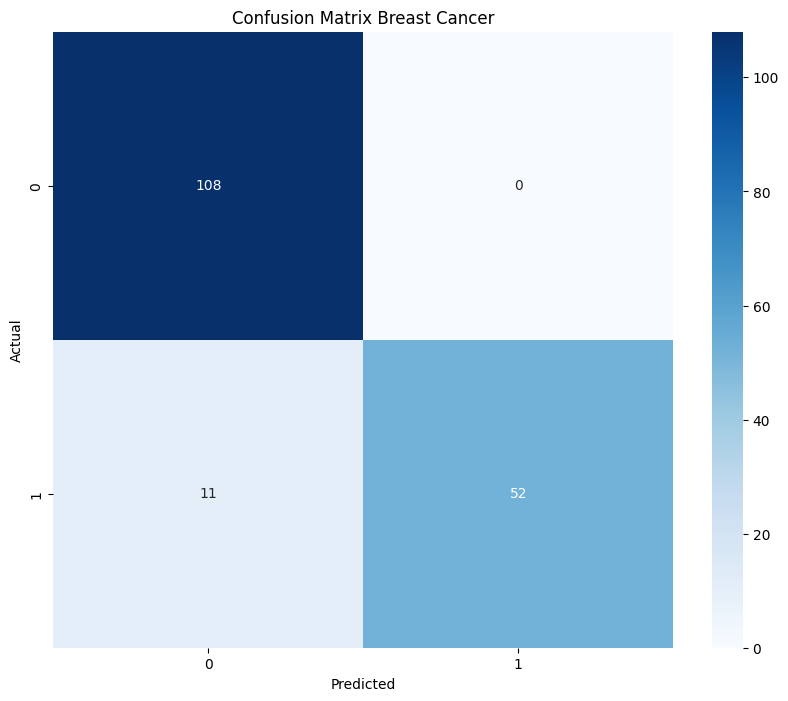


Total test samples: 171
Correctly classified: 160
Incorrectly classified: 11


In [67]:
#this shows us how well the model performed and where it made mistakes.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Breast Cancer')
plt.show()


print(f"\nTotal test samples: {len(y_test)}")
print(f"Correctly classified: {(y_test == y_pred).sum()}")
print(f"Incorrectly classified: {(y_test != y_pred).sum()}")

In [66]:
print("\n" + "="*70)
print("EXPLANATION:")
print("="*70)
print("This program shows how a Support Vector Machine can classify breast cancer")
print("as malignant or benign using different medical measurements.")
print("The RBF kernel is used because the data is not separable with a straight line.")
print("After training the model, we test it on new data to see how it performs.")
print("The model predicts whether a player scores 15 or more points per game")
print("The confusion matrix shows how accurate the predictions are.")
print("="*70)


EXPLANATION:
This program shows how a Support Vector Machine can classify breast cancer
as malignant or benign using different medical measurements.
The RBF kernel is used because the data is not separable with a straight line.
After training the model, we test it on new data to see how it performs.
The model predicts whether a player scores 15 or more points per game
The confusion matrix shows how well the model performs on unseen data.
